In [37]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.ticker as mticker

sns.set_style("whitegrid")

In [38]:
# models : "BPR", "VAE", "NCF", "SVD"
legend_plot = "VAE/Per_items/VAE_Yelp_ndcg_per_category_LDP.pdf"  # This is the saving path of the plot that has legend
paths = ["BPR", "VAE", "NCF", "SVD"]  # all models

In [39]:
common_metrics = [
    'KLD_test', 'NDCG_test', 'recall_test', 'Total MRR',
    'normal_PL', 'novelty_normal',
    'Coverage', 'normalized_DPF',
    'normalized_exposure_1', 'normalized_exposure_2'
]

model_configs = {
    'BPR': {
        'csv_files': [
            'BPR_1M_LDP.csv', 'BPR_1M_DPSGD.csv',  # csv files that include our results
            'BPR_Yelp_LDP.csv', 'BPR_Yelp_DPSGD.csv'
        ],
        'normal_model_name': ["1M_BPR_50", "BPR_YELP"],
        'normal_names': ['1M_BPR_50', "", 'BPR_YELP'],
        'model_labels': ['BPR_1M', "", 'BPR_YELP'],
        'metrics': common_metrics
    },
    'SVD': {
        'csv_files': [
            'SVD_1M_LDP.csv', 'SVD_1M_DPSGD.csv',
            'SVD_Yelp_LDP.csv', 'SVD_Yelp_DPSGD.csv'
        ],
        'normal_model_name': ["1M_SVD_50", "SVD_Yelp_50"],
        'normal_names': ['1M_SVD_50', "", 'SVD_Yelp_50'],
        'model_labels': ['SVD_1M', "", 'SVD_Yelp'],
        'metrics': common_metrics
    },
    'VAE': {
        'csv_files': [
            'VAE_1M_LDP.csv', 'VAE_1M_DPSGD.csv',
            'VAE_Yelp_LDP.csv', 'VAE_Yelp_DPSGD.csv'
        ],
        'normal_model_name': ["vae_1M", "vae_Yelp"],
        'normal_names': ['vae_1M', "", 'vae_Yelp'],
        'model_labels': ['VAE_1M', "", 'VAE_Yelp'],
        'metrics': [m for m in common_metrics if m != 'Total MRR']
    },
    'NCF': {
        'csv_files': [
            'Deep_1M_LDP.csv', 'Deep_1M_DPSGD.csv',
            'Deep_Yelp_LDP.csv', 'Deep_Yelp_DPSGD.csv'
        ],
        'normal_model_name': ["Deep_1M_50", 'Yelp_Deep_50'],
        'normal_names': ['Deep_1M_50', "", 'Yelp_Deep_50'],
        'model_labels': ['NCF_1M', "", 'NCF_Yelp'],
        'metrics': common_metrics
    }
}

In [40]:
import ast


def safe_literal_eval(val):
    """Safely evaluate a string as a literal, return original if already a dictionary."""
    if isinstance(val, str):  # Only convert if it's a string
        try:
            #print(val)
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            print(f"Skipping conversion for: {val}")  # Debugging output
            return val  # Return as is if it's not properly formatted
    return val  # Return as is if it's already a dictionary


def scales_items(df_dp, df_dpsgd, column_name):
    print(column_name)
    df_dpsgd[column_name] = df_dpsgd[column_name].apply(safe_literal_eval)
    df_dp[column_name] = df_dp[column_name].apply(safe_literal_eval)
    df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
    df_dpsgd['PL_I2'] = df_dpsgd[column_name].apply(lambda x: x.get('I2', None))
    df_dp['PL_I1'] = df_dp[column_name].apply(lambda x: x.get('I1', None))
    df_dp['PL_I2'] = df_dp[column_name].apply(lambda x: x.get('I2', None))
    mean_I1_dpsgd = df_dpsgd.groupby('noise_multiplier')['PL_I1'].mean()
    std_I1_dpsgd = df_dpsgd.groupby('noise_multiplier')['PL_I1'].std()
    mean_I2_dpsgd = df_dpsgd.groupby('noise_multiplier')['PL_I2'].mean()
    std_I2_dpsgd = df_dpsgd.groupby('noise_multiplier')['PL_I2'].std()
    epsilon_values_dpsgd = df_dpsgd.groupby('noise_multiplier')['epsilon'].mean()
    sorted_indices = mean_I1_dpsgd.index[::-1]
    mean_I1_dpsgd = mean_I1_dpsgd.loc[sorted_indices]
    std_I1_dpsgd = std_I1_dpsgd.loc[sorted_indices]
    mean_I2_dpsgd = mean_I2_dpsgd.loc[sorted_indices]
    std_I2_dpsgd = std_I2_dpsgd.loc[sorted_indices]
    epsilon_values_dpsgd = epsilon_values_dpsgd.loc[sorted_indices]

    mean_I1_dp = df_dp.groupby('epsilon')['PL_I1'].mean()
    std_I1_dp = df_dp.groupby('epsilon')['PL_I1'].std()
    mean_I2_dp = df_dp.groupby('epsilon')['PL_I2'].mean()
    std_I2_dp = df_dp.groupby('epsilon')['PL_I2'].std()

    y_min = min(
        mean_I1_dpsgd.min() - std_I1_dpsgd.max(),
        mean_I2_dpsgd.min() - std_I2_dpsgd.max(),
        mean_I1_dp.min() - std_I1_dp.max(),
        mean_I2_dp.min() - std_I2_dp.max()
    )

    y_max = max(
        mean_I1_dpsgd.max() + std_I1_dpsgd.max(),
        mean_I2_dpsgd.max() + std_I2_dpsgd.max(),
        mean_I1_dp.max() + std_I1_dp.max(),
        mean_I2_dp.max() + std_I2_dp.max()
    )
    return y_min, y_max




In [41]:
#### Epsilon Based (Items)

def plot_item_based_epsilon_logscale(df_dp, df_dpsgd, normal_name, metric, model_name_sh, scales_items_dict,
                                     path_save_base, legend_plot):
    df_dpsgd.loc[df_dpsgd['model_name'] == normal_name, 'noise_multiplier'] = 0
    df_normal = df_dpsgd[df_dpsgd['model_name'] == normal_name]
    df_dpsgd = df_dpsgd[df_dpsgd['model_name'] != normal_name]

    column_name = metric
    label_name = metric.split('_')[0].upper()

    # Convert string dict to actual dictionary
    for df in [df_dpsgd, df_dp, df_normal]:
        df[column_name] = df[column_name].apply(ast.literal_eval)

    # Extract 'I1' and 'I2' values
    df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
    df_dpsgd['PL_I2'] = df_dpsgd[column_name].apply(lambda x: x.get('I2', None))
    df_normal['PL_I1'] = df_normal[column_name].apply(lambda x: x.get('I1', None))
    df_normal['PL_I2'] = df_normal[column_name].apply(lambda x: x.get('I2', None))
    df_dp['PL_I1'] = df_dp[column_name].apply(lambda x: x.get('I1', None))
    df_dp['PL_I2'] = df_dp[column_name].apply(lambda x: x.get('I2', None))

    normal_PL_I1 = df_normal['PL_I1'].mean()
    normal_PL_I2 = df_normal['PL_I2'].mean()

    y_min = scales_items_dict[0]
    y_max = scales_items_dict[-1]

    if metric == 'ndcg_per_category':
        y_min = 0

    if (metric == 'PL_per_category') & (path == 'VAE'):
        y_max = 4
    if (metric == 'kld_pre_category') & (path == 'SVD'):
        y_min = 0

    # path_save_ax1 = path_save_base.replace(".pdf", "_DPSGD.pdf")
    fig1, ax1 = plt.subplots(figsize=(3, 2.5))
    fig1.patch.set_facecolor('white')
    ax1.set_facecolor('white')
    ax1.set_xlim(0.008, 406)  # min/max epsilon over all datasets as of 2025-07-17

    sns.lineplot(x='epsilon', y='PL_I1', data=df_dpsgd[['PL_I1', 'epsilon']], ax=ax1,
                 errorbar=('ci', 95), err_style='bars', err_kws={'fmt': '.', 'ecolor': 'black'},
                 label=f'I1, DPSGD', color=sns.color_palette("Paired")[0])

    sns.lineplot(x='epsilon', y='PL_I2', data=df_dpsgd[['PL_I2', 'epsilon']], ax=ax1,
                 errorbar=('ci', 95), err_style='bars', err_kws={'fmt': '.', 'ecolor': 'black'},
                 label=f'I2, DPSGD', color=sns.color_palette("Paired")[1])

    sns.lineplot(x='epsilon', y='PL_I1', data=df_dp[['PL_I1', 'epsilon']], ax=ax1,
                 errorbar=('ci', 95), err_style='bars', err_kws={'fmt': '.', 'ecolor': 'black'},
                 label=f'I1, LDP', color=sns.color_palette("Paired")[2])

    sns.lineplot(x='epsilon', y='PL_I2', data=df_dp[['PL_I2', 'epsilon']], ax=ax1,
                 errorbar=('ci', 95), err_style='bars', err_kws={'fmt': '.', 'ecolor': 'black'},
                 label=f'I2, LDP', color=sns.color_palette("Paired")[3])

    ax1.axhline(y=normal_PL_I1, color=sns.color_palette("Paired")[0], linestyle='--', linewidth=1,
                label=f'I1 w/o privacy')
    ax1.axhline(y=normal_PL_I2, color=sns.color_palette("Paired")[1], linestyle='--', linewidth=1,
                label=f'I2 w/o privacy')

    ax1.set_xlabel('Epsilon')
    ax1.set_ylabel(label_name)
    ax1.set_xscale('log', base=10)
    locmin = mticker.LogLocator(base=10, subs=np.arange(0.1, 1, 0.1), numticks=10)
    ax1.xaxis.set_minor_locator(locmin)
    ax1.set_ylim(y_min, y_max)
    ax1.legend()
    if model_name != "NCF_1M":
        ax1.get_legend().remove()
    sns.despine()
    plt.tight_layout()
    plt.savefig(path_save_base, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig1)

    # path_save_ax2 = path_save_base.replace(".pdf", "_LDP.pdf")
    # fig2, ax2 = plt.subplots(figsize=(3, 2.5))
    # fig2.patch.set_facecolor('white')
    # ax2.set_facecolor('white')
    # ax1.set_xlim(0.008, 406)  # min/max epsilon over all datasets as of 2025-07-17
    #
    # sns.lineplot(x='epsilon', y='PL_I1', data=df_dp[['PL_I1', 'epsilon']], ax=ax2,
    #              errorbar=('ci', 95), err_style='bars', err_kws={'fmt': '.', 'ecolor': 'black'},
    #              label=f'I1 with privacy', color=sns.color_palette("Paired")[0])
    #
    # sns.lineplot(x='epsilon', y='PL_I2', data=df_dp[['PL_I2', 'epsilon']], ax=ax2,
    #              errorbar=('ci', 95), err_style='bars', err_kws={'fmt': '.', 'ecolor': 'black'},
    #              label=f'I2 with privacy', color=sns.color_palette("Paired")[2])
    #
    # ax2.axhline(y=normal_PL_I1, color=sns.color_palette("Paired")[0], linestyle='--', linewidth=1, label=f'I1 without privacy')
    # ax2.axhline(y=normal_PL_I2, color=sns.color_palette("Paired")[2], linestyle='--', linewidth=1, label=f'I2 without privacy')
    #
    # #ax2.set_title(f'{label_name} ({model_name_sh}) - LDP')
    # ax2.set_xlabel('Epsilon')
    # ax2.set_ylabel(label_name)
    # ax2.set_xscale('log', base=10)
    # locmin = mticker.LogLocator(base=10, subs=np.arange(0.1, 1, 0.1), numticks=10)
    # ax2.xaxis.set_minor_locator(locmin)
    # ax2.set_ylim(y_min, y_max)
    # ax2.legend()
    # if path_save_ax2 != legend_plot:
    #     ax2.get_legend().remove()
    # sns.despine()
    # plt.tight_layout()
    #
    # plt.savefig(path_save_ax2, format='pdf', bbox_inches='tight', dpi=300)
    # plt.show()
    # plt.close(fig2)
    #
    # print(f"Saved plots: {path_save_ax1}, {path_save_ax2}")


PL_per_category
inside: PL_per_category:y_min: inf, y_max: -100
PL_per_category
inside: PL_per_category:y_min: -0.7118680008143423, y_max: 0.712652120999982
outside: PL_per_category:y_min: -0.7118680008143423, y_max: 0.712652120999982
scales: {'PL_per_category': [-0.7118680008143423, 0.712652120999982]}
kld_pre_category
inside: kld_pre_category:y_min: inf, y_max: -100
kld_pre_category
inside: kld_pre_category:y_min: 0.13853074943221844, y_max: 0.923495732305332
outside: kld_pre_category:y_min: 0.13853074943221844, y_max: 2.0348083363460763
scales: {'PL_per_category': [-0.7118680008143423, 0.712652120999982], 'kld_pre_category': [0.13853074943221844, 2.0348083363460763]}
ndcg_per_category
inside: ndcg_per_category:y_min: inf, y_max: -100
ndcg_per_category
inside: ndcg_per_category:y_min: 0.005849109817177289, y_max: 0.43384166604666047
outside: ndcg_per_category:y_min: -0.006187865198486436, y_max: 0.5402518972221002
scales: {'PL_per_category': [-0.7118680008143423, 0.712652120999982], 

/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

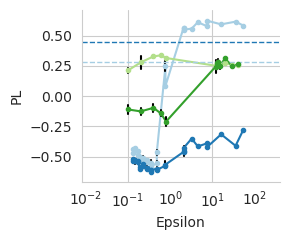

BPR_YELP


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

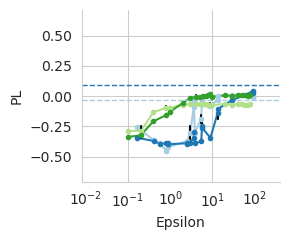

1M_BPR_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

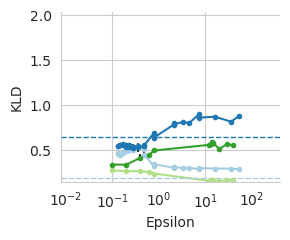

BPR_YELP


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

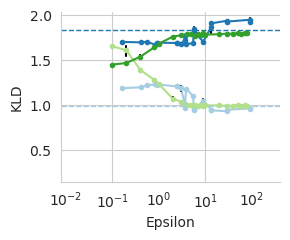

1M_BPR_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

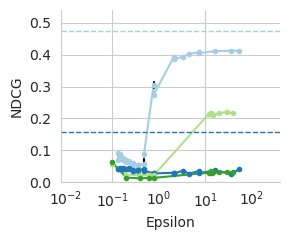

BPR_YELP


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

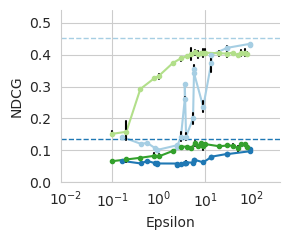

PL_per_category
inside: PL_per_category:y_min: inf, y_max: -100
PL_per_category
inside: PL_per_category:y_min: -1.0244718687541023, y_max: 1.2105983234192057
outside: PL_per_category:y_min: -1.0244718687541023, y_max: 1.6718202667042363
scales: {'PL_per_category': [-1.0244718687541023, 1.6718202667042363]}
kld_pre_category
inside: kld_pre_category:y_min: inf, y_max: -100
kld_pre_category
inside: kld_pre_category:y_min: 0.18928447242242216, y_max: 1.2625681717363975
outside: kld_pre_category:y_min: 0.18928447242242216, y_max: 7.259461908707605
scales: {'PL_per_category': [-1.0244718687541023, 1.6718202667042363], 'kld_pre_category': [0.18928447242242216, 7.259461908707605]}
ndcg_per_category
inside: ndcg_per_category:y_min: inf, y_max: -100
ndcg_per_category
inside: ndcg_per_category:y_min: -0.06501888765067756, y_max: 0.247728749268946
outside: ndcg_per_category:y_min: -0.06501888765067756, y_max: 0.247728749268946
scales: {'PL_per_category': [-1.0244718687541023, 1.6718202667042363], 

/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

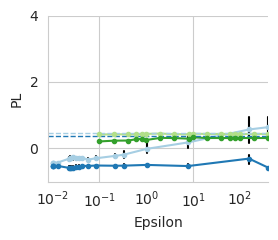

vae_Yelp


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

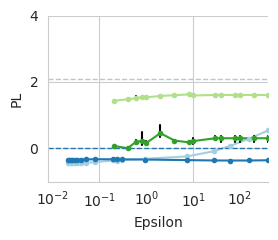

vae_1M


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

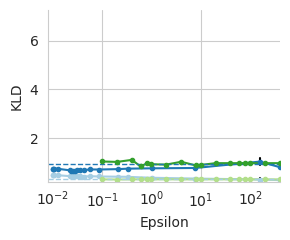

vae_Yelp


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

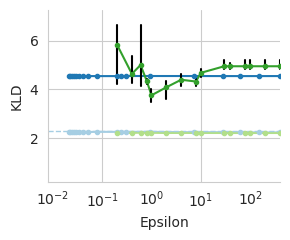

vae_1M


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

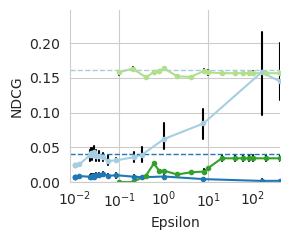

vae_Yelp


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

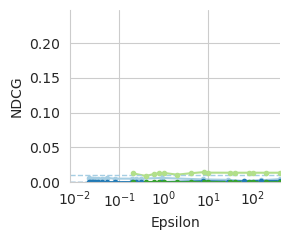

PL_per_category
inside: PL_per_category:y_min: inf, y_max: -100
PL_per_category
inside: PL_per_category:y_min: -0.8204844496087391, y_max: 1.024721959915932
outside: PL_per_category:y_min: -0.8204844496087391, y_max: 1.024721959915932
scales: {'PL_per_category': [-0.8204844496087391, 1.024721959915932]}
kld_pre_category
inside: kld_pre_category:y_min: inf, y_max: -100
kld_pre_category
inside: kld_pre_category:y_min: 0.14064750846048235, y_max: 1.3425009336335807
outside: kld_pre_category:y_min: 0.14064750846048235, y_max: 4.926586813279156
scales: {'PL_per_category': [-0.8204844496087391, 1.024721959915932], 'kld_pre_category': [0.14064750846048235, 4.926586813279156]}
ndcg_per_category
inside: ndcg_per_category:y_min: inf, y_max: -100
ndcg_per_category
inside: ndcg_per_category:y_min: -0.06463638416383187, y_max: 0.7645845764487202
outside: ndcg_per_category:y_min: -0.06463638416383187, y_max: 0.7645845764487202
scales: {'PL_per_category': [-0.8204844496087391, 1.024721959915932], 'kl

/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

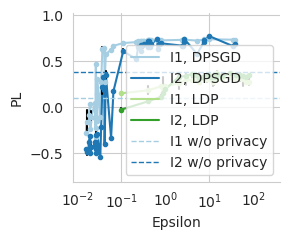

Yelp_Deep_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

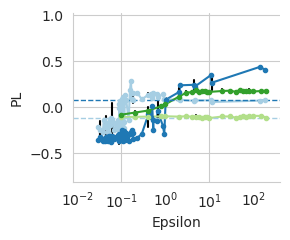

Deep_1M_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

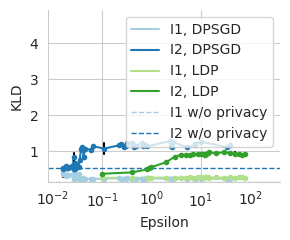

Yelp_Deep_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

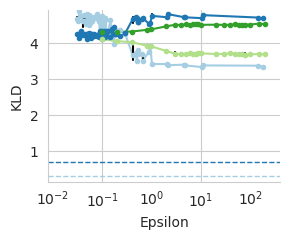

Deep_1M_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

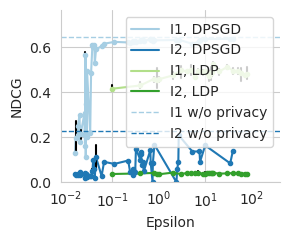

Yelp_Deep_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

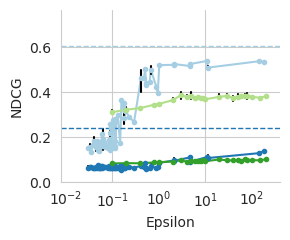

PL_per_category
inside: PL_per_category:y_min: inf, y_max: -100
PL_per_category
inside: PL_per_category:y_min: -0.8854710009572474, y_max: 1.1687690535346578
outside: PL_per_category:y_min: -0.8854710009572474, y_max: 1.1687690535346578
scales: {'PL_per_category': [-0.8854710009572474, 1.1687690535346578]}
kld_pre_category
inside: kld_pre_category:y_min: inf, y_max: -100
kld_pre_category
inside: kld_pre_category:y_min: 0.12413359352385654, y_max: 1.322790495849191
outside: kld_pre_category:y_min: 0.12413359352385654, y_max: 1.915042665262873
scales: {'PL_per_category': [-0.8854710009572474, 1.1687690535346578], 'kld_pre_category': [0.12413359352385654, 1.915042665262873]}
ndcg_per_category
inside: ndcg_per_category:y_min: inf, y_max: -100
ndcg_per_category
inside: ndcg_per_category:y_min: -0.12494590722990216, y_max: 0.756106695926679
outside: ndcg_per_category:y_min: -0.12494590722990216, y_max: 0.756106695926679
scales: {'PL_per_category': [-0.8854710009572474, 1.1687690535346578], '

/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

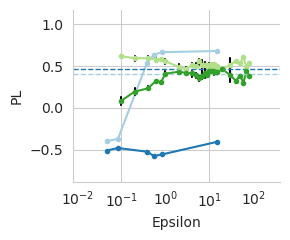

SVD_Yelp_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

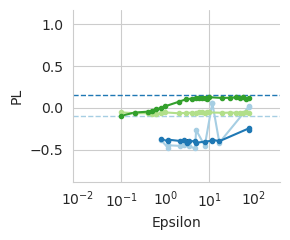

1M_SVD_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

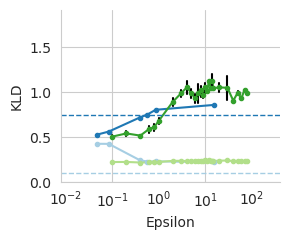

SVD_Yelp_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

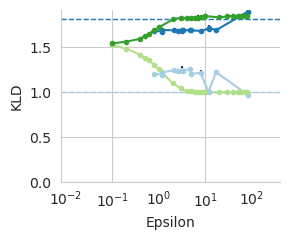

1M_SVD_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

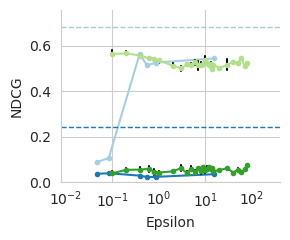

SVD_Yelp_50


/tmp/ipykernel_95812/66793112.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].apply(ast.literal_eval)
/tmp/ipykernel_95812/66793112.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dpsgd['PL_I1'] = df_dpsgd[column_name].apply(lambda x: x.get('I1', None))
/tmp/ipykernel_95812/66793112.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

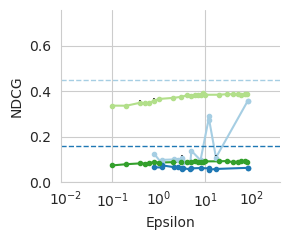

In [42]:
metrics_item_based = ['PL_per_category', 'kld_pre_category', 'ndcg_per_category']
for path in paths:
    dataset = model_configs[path]
    scales_items_dict = {}
    for i, metric in enumerate(metrics_item_based):
        y_max = -100
        y_min = float("inf")
        for i in range(0, len(dataset['csv_files']), 2):

            df_mechanism1 = pd.read_csv(os.path.join("csv_files", dataset['csv_files'][i]))
            df_mechanism2 = pd.read_csv(os.path.join("csv_files", dataset['csv_files'][i + 1]))
            x_min_init, x_max_init = scales_items(df_mechanism1, df_mechanism2, metric)
            print(f"inside: {metric}:y_min: {y_min}, y_max: {y_max}")
            if x_min_init < y_min:
                y_min = x_min_init
            if x_max_init > y_max:
                y_max = x_max_init
        print(f"outside: {metric}:y_min: {y_min}, y_max: {y_max}")
        scales_items_dict[metric] = [y_min, y_max]
        if metric == 'ndcg_per_category':
            scales_items_dict[metric] = [0, y_max]
        print(f"scales: {scales_items_dict}")

    if path == 'BPR':
        name = 'BPR'
    elif path == 'NCF':
        name = 'NCF'
    elif path == 'SVD':
        name = 'SVD'
    elif path == 'VAE':
        name = 'VAE'
    new_path = os.path.join(path, 'Per_items')
    if not os.path.exists(new_path):
        os.makedirs(new_path)
    for i, metric in enumerate(metrics_item_based):
        for i in range(0, len(dataset['csv_files']), 2):
            df_mechanism1 = pd.read_csv(os.path.join("csv_files", dataset['csv_files'][i]))
            df_mechanism2 = pd.read_csv(os.path.join("csv_files", dataset['csv_files'][i + 1]))

            model_name = dataset['model_labels'][i]
            print(dataset['normal_names'][i])

            file_name = f'{model_name}_{metric}.pdf'
            path_save = os.path.join(new_path, file_name)

            plot_item_based_epsilon_logscale(df_mechanism1, df_mechanism2, dataset['normal_names'][i], metric,
                                             model_name, scales_items_dict[metric], path_save, legend_plot)




